In [1]:
import pandas as pd
import numpy as np

## Load the age and the sex for the UK BioBank subjects

In [ ]:
sex_age_df = pd.read_csv("/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/participants_sex_age.csv")
sex_age_df

array([[<Axes: title={'center': 'Sex'}>, <Axes: title={'center': 'Age'}>]],
      dtype=object)

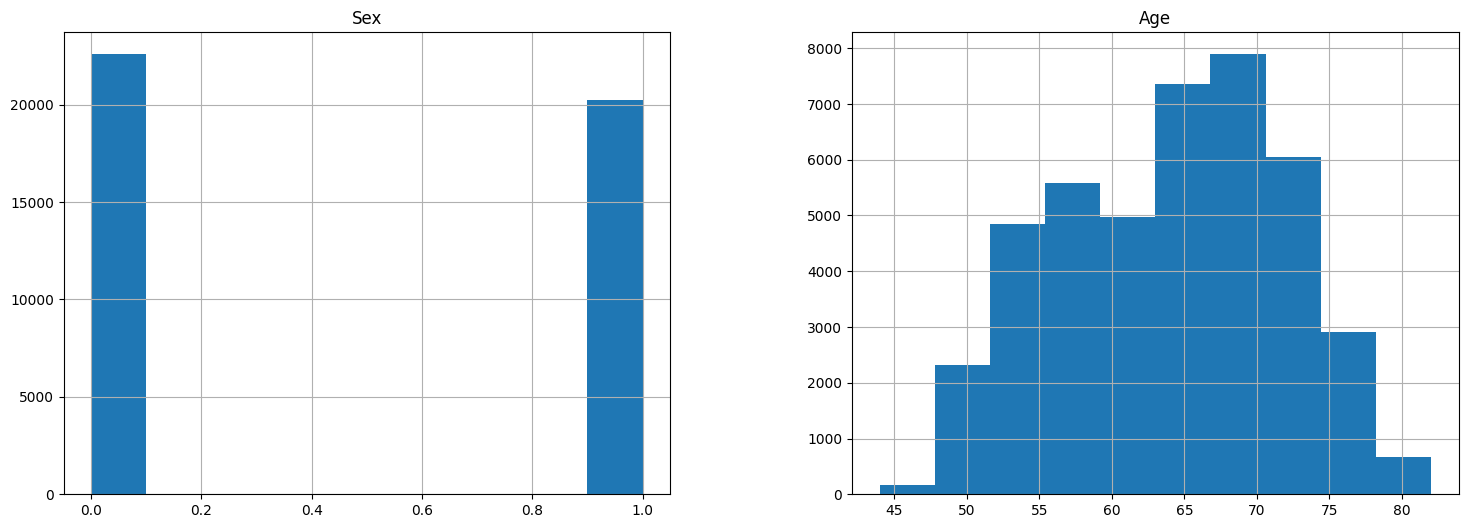

In [3]:
sex_age_df.hist(figsize=(18, 6))

### Split the dataset into 10 deciles, based on the age

In [ ]:
# adding Decile_rank column to the DataFrame 
sex_age_df['Decile_rank'] = pd.qcut(sex_age_df['Age'], 10, 
                            labels = False)
sex_age_df

#### Chech the proportion of male and female in the first decile (the "young" subjects)

In [ ]:
print(sex_age_df[sex_age_df["Decile_rank"]==0].head(), '\n')
print(sex_age_df[sex_age_df["Decile_rank"]==0].shape, '\n')
print(sex_age_df[sex_age_df["Decile_rank"]==0]["Age"].min(), '\n')
print(sex_age_df[sex_age_df["Decile_rank"]==0]["Age"].max(), '\n')
(sex_age_df[sex_age_df["Decile_rank"]==0][["Sex","Age"]]).mean()


#### Chech the proportion of male and female in the last decile (the "old" subjects)

In [ ]:
print(sex_age_df[sex_age_df["Decile_rank"]==9].head(), '\n')
print(sex_age_df[sex_age_df["Decile_rank"]==9].shape, '\n')
print(sex_age_df[sex_age_df["Decile_rank"]==9]["Age"].min(), '\n')
print(sex_age_df[sex_age_df["Decile_rank"]==9]["Age"].max(), '\n')
(sex_age_df[sex_age_df["Decile_rank"]==9][["Sex","Age"]]).mean()

### Load the quality check files

In [7]:
QC0 = pd.read_csv("/volatile/ad279118/2024_adufournet_sulcus_genetics/notebooks/UKB/QC/outliers.csv")
QC0 = QC0["ID"].to_list()
# we don't want to be in QC0

In [ ]:
QC1 = pd.read_csv("/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/qc.tsv", sep="\t")
QC1 = QC1[QC1["qc"]==1]["participant_id"]
QC1
# we want to be in QC0

### Pick randomly 
  - 25 females among the first decile

  - 25 males among the first decile

  - 25 females among the last decile

  - 25 males among the last decile

  that are all good according to both QC

In [9]:
seed=42

In [ ]:
firstDecile = sex_age_df[sex_age_df["Decile_rank"]==0]
firstDecile = pd.merge(firstDecile, QC1, left_on='Subject', right_on='participant_id', how='inner')
firstDecile = firstDecile.drop(["participant_id","Decile_rank"], axis=1)
firstDecile = firstDecile[~firstDecile["Subject"].isin(QC0)]

firstDecile[firstDecile["Sex"]==1].sample(n=25, random_state=seed)


In [ ]:
lastDecile = sex_age_df[sex_age_df["Decile_rank"]==9]
lastDecile = pd.merge(lastDecile, QC1, left_on='Subject', right_on='participant_id', how='inner')
lastDecile = lastDecile.drop(["participant_id","Decile_rank"], axis=1)
lastDecile = lastDecile[~lastDecile["Subject"].isin(QC0)]

lastDecile[lastDecile["Sex"]==1].sample(n=25, random_state=seed)

In [12]:
df_subjects = (firstDecile[firstDecile["Sex"]==0].sample(n=25, random_state=seed))
df_subjects = pd.concat([df_subjects, firstDecile[firstDecile["Sex"]==1].sample(n=25, random_state=seed)])
df_subjects = pd.concat([df_subjects,lastDecile[lastDecile["Sex"]==0].sample(n=25, random_state=seed)])
df_subjects = pd.concat([df_subjects,lastDecile[lastDecile["Sex"]==1].sample(n=25, random_state=seed)])

In [20]:
df_subjects[(df_subjects["Age"]>60)].describe()

,Sex,Age
count,50.000000,50.000000
mean,0.500000,76.480000
std,0.505076,1.474131
min,0.000000,75.000000
25%,0.000000,75.000000
50%,0.500000,76.000000
75%,1.000000,77.750000
max,1.000000,80.000000


In [62]:
df_subjects.to_csv('/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/PCS_annotation/100_SEX_AGE_strat.csv', index=False)